In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pickle
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/irrigation.csv')
print("Shape:", df.shape)
print(df['Irrigation_Need'].value_counts())

Shape: (10000, 20)
Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64


In [2]:
# Numeric features — directly useful for irrigation decision
numeric_features = [
    'Soil_Moisture',
    'Temperature_C',
    'Humidity',
    'Rainfall_mm',
    'Soil_pH',
    'Sunlight_Hours',
    'Wind_Speed_kmh',
    'Organic_Carbon',
    'Electrical_Conductivity',
    'Previous_Irrigation_mm',
    'Field_Area_hectare'
]

# Categorical features — encode these
categorical_features = [
    'Soil_Type',
    'Crop_Type',
    'Crop_Growth_Stage',
    'Season',
    'Mulching_Used',
    'Region'
]

# We drop: Irrigation_Type, Water_Source
# Reason: these describe HOW water is delivered, not WHETHER it's needed
# They could leak information in a real system

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 11
Categorical features: 6


In [3]:
df_model = df.copy()

# Encode categorical input features using LabelEncoder
le_dict = {}  # store encoders for later use

for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable — fixed mapping for interpretability
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_model['Irrigation_Need'] = df_model['Irrigation_Need'].map(target_map)

print("\nTarget encoding:", target_map)
print(df_model['Irrigation_Need'].value_counts())

Soil_Type: {'Clay': np.int64(0), 'Loamy': np.int64(1), 'Sandy': np.int64(2), 'Silt': np.int64(3)}
Crop_Type: {'Cotton': np.int64(0), 'Maize': np.int64(1), 'Potato': np.int64(2), 'Rice': np.int64(3), 'Sugarcane': np.int64(4), 'Wheat': np.int64(5)}
Crop_Growth_Stage: {'Flowering': np.int64(0), 'Harvest': np.int64(1), 'Sowing': np.int64(2), 'Vegetative': np.int64(3)}
Season: {'Kharif': np.int64(0), 'Rabi': np.int64(1), 'Zaid': np.int64(2)}
Mulching_Used: {'No': np.int64(0), 'Yes': np.int64(1)}
Region: {'Central': np.int64(0), 'East': np.int64(1), 'North': np.int64(2), 'South': np.int64(3), 'West': np.int64(4)}

Target encoding: {'Low': 0, 'Medium': 1, 'High': 2}
Irrigation_Need
0    5864
1    3800
2     336
Name: count, dtype: int64


In [4]:
all_features = numeric_features + categorical_features

X = df_model[all_features]
y = df_model['Irrigation_Need']

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

# Check imbalance ratio
print("\nImbalance ratio:")
for label, name in [(0,'Low'),(1,'Medium'),(2,'High')]:
    print(f"  {name}: {(y==label).sum()} ({(y==label).mean()*100:.1f}%)")

X shape: (10000, 17)
y distribution:
 Irrigation_Need
0    5864
1    3800
2     336
Name: count, dtype: int64

Imbalance ratio:
  Low: 5864 (58.6%)
  Medium: 3800 (38.0%)
  High: 336 (3.4%)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures same class ratio in train and test
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train size: (8000, 17)
Test size: (2000, 17)

Train class distribution:
 Irrigation_Need
0    4691
1    3040
2     269
Name: count, dtype: int64

Test class distribution:
 Irrigation_Need
0    1173
1     760
2      67
Name: count, dtype: int64


In [6]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'   # handles class imbalance
)

dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, dt_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, dt_preds, target_names=['Low','Medium','High']))

=== Decision Tree ===
Accuracy: 99.25%

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1173
      Medium       0.99      0.99      0.99       760
        High       0.95      0.90      0.92        67

    accuracy                           0.99      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000



In [7]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',   # handles imbalance
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Low','Medium','High']))

=== Random Forest ===
Accuracy: 98.45%

Classification Report:
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00      1173
      Medium       0.96      1.00      0.98       760
        High       1.00      0.58      0.74        67

    accuracy                           0.98      2000
   macro avg       0.99      0.86      0.90      2000
weighted avg       0.98      0.98      0.98      2000



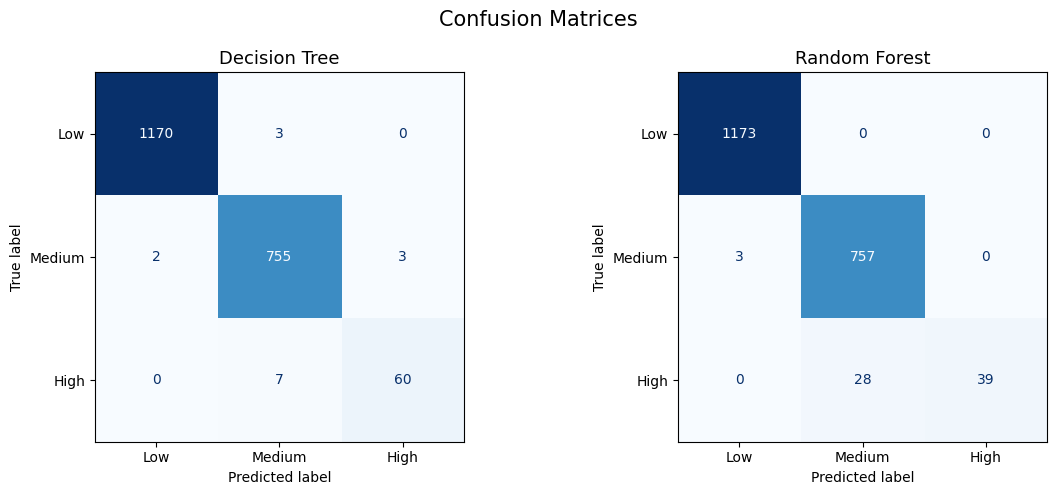

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in zip(axes, [dt_preds, rf_preds], ['Decision Tree', 'Random Forest']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low','Medium','High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}', fontsize=13)

plt.suptitle('Confusion Matrices', fontsize=15)
plt.tight_layout()
plt.show()

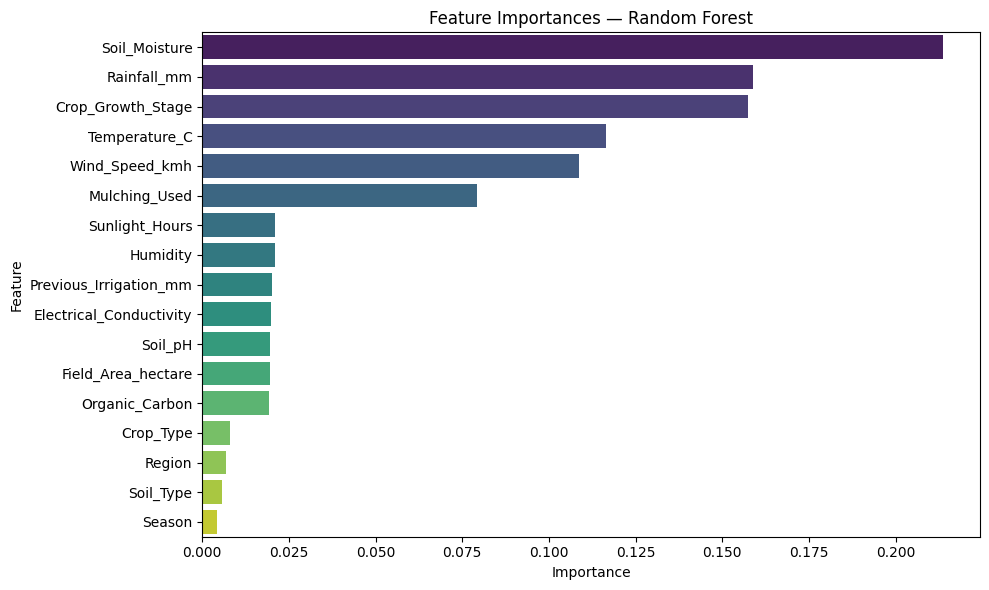

                Feature  Importance
          Soil_Moisture    0.213631
            Rainfall_mm    0.158992
      Crop_Growth_Stage    0.157286
          Temperature_C    0.116587
         Wind_Speed_kmh    0.108697
          Mulching_Used    0.079282
         Sunlight_Hours    0.021142
               Humidity    0.020867
 Previous_Irrigation_mm    0.020248
Electrical_Conductivity    0.019722
                Soil_pH    0.019587
     Field_Area_hectare    0.019555
         Organic_Carbon    0.019321
              Crop_Type    0.007917
                 Region    0.006999
              Soil_Type    0.005805
                 Season    0.004364


In [9]:
importances = rf_model.feature_importances_
feature_names = all_features

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print(feat_df.to_string(index=False))

In [12]:
import os

os.makedirs('../models', exist_ok=True)

# Save Decision Tree (better performance, especially on High class)
with open('../models/irrigation_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)

# Save label encoders
with open('../models/label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)

# Save feature names
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(all_features, f)

# Save target mapping
target_map = {'Low': 0, 'Medium': 1, 'High': 2}
with open('../models/target_map.pkl', 'wb') as f:
    pickle.dump(target_map, f)

print(" Decision Tree model saved → models/irrigation_model.pkl")
print(" Label encoders saved     → models/label_encoders.pkl")
print(" Feature names saved      → models/feature_names.pkl")
print(" Target map saved         → models/target_map.pkl")

 Decision Tree model saved → models/irrigation_model.pkl
 Label encoders saved     → models/label_encoders.pkl
 Feature names saved      → models/feature_names.pkl
 Target map saved         → models/target_map.pkl
